In [4]:
import urllib.request
import pandas as pd

In [5]:
with urllib.request.urlopen("https://raw.githubusercontent.com/Somon8/social_graphs_25/main/final-project/folketinget_votings_enriched.csv") as response:
    df_votings = pd.read_csv(response)

In [ ]:
df_votings

In [6]:
df_votings_type1 = df_votings[df_votings['typeid_afstemning'] == 1]

In [ ]:
df_votings_type1

In [11]:
df_votings_type1 = df_votings_type1.copy()
df_votings_type1['topic_texts'] = df_votings_type1['titel'] + " " + df_votings_type1['resume'].fillna('')

FOLKETINGET TOPIC CLASSIFICATION PIPELINE

[1/5] Stemming keywords...
      14 topics with 179 total stemmed keywords

[2/5] Classifying 5957 cases...
      Done!

[3/5] Computing statistics...

      COVERAGE STATISTICS:
      Total cases:      5957
      Classified:       5666 (95.1%)
      Unclassified:     291 (4.9%)
      Multi-topic:      4592 (77.1%)

      TOPIC STATISTICS:
                  topic  primary_count  any_count  avg_score_when_present
                erhverv            713       2165                    1.58
            klima_miljø            625       1016                    1.63
                sundhed            567       1299                    1.58
                   skat            562        981                    1.97
             uddannelse            534       1030                    1.98
          finans_budget            469       1667                    1.43
            retspolitik            462       1472                    1.58
  arbejdsmarked_velfærd

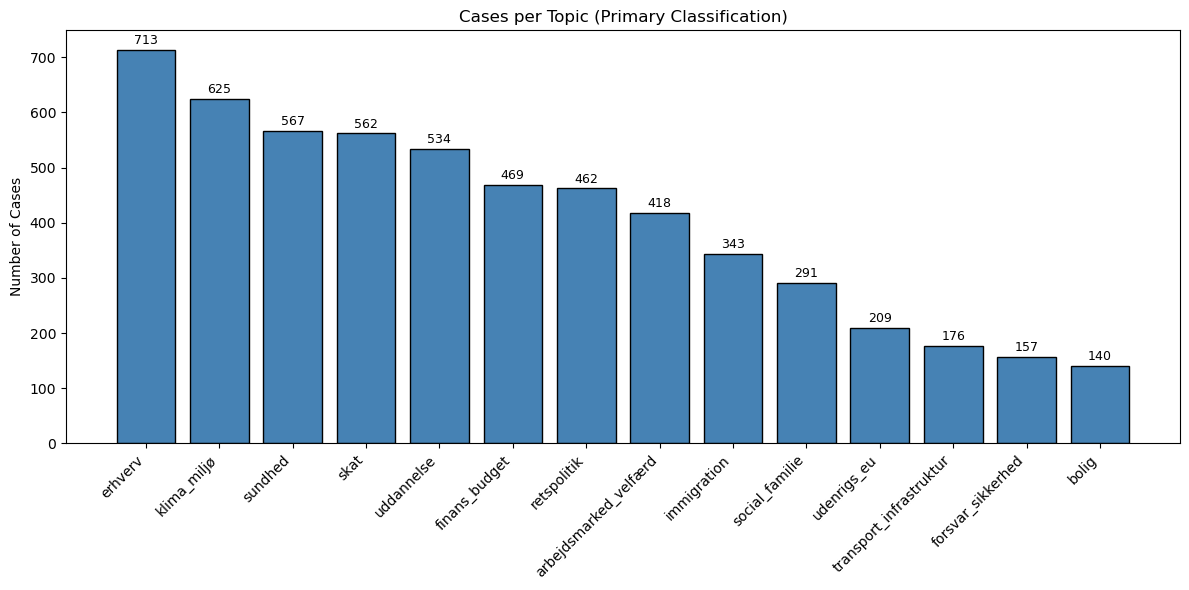

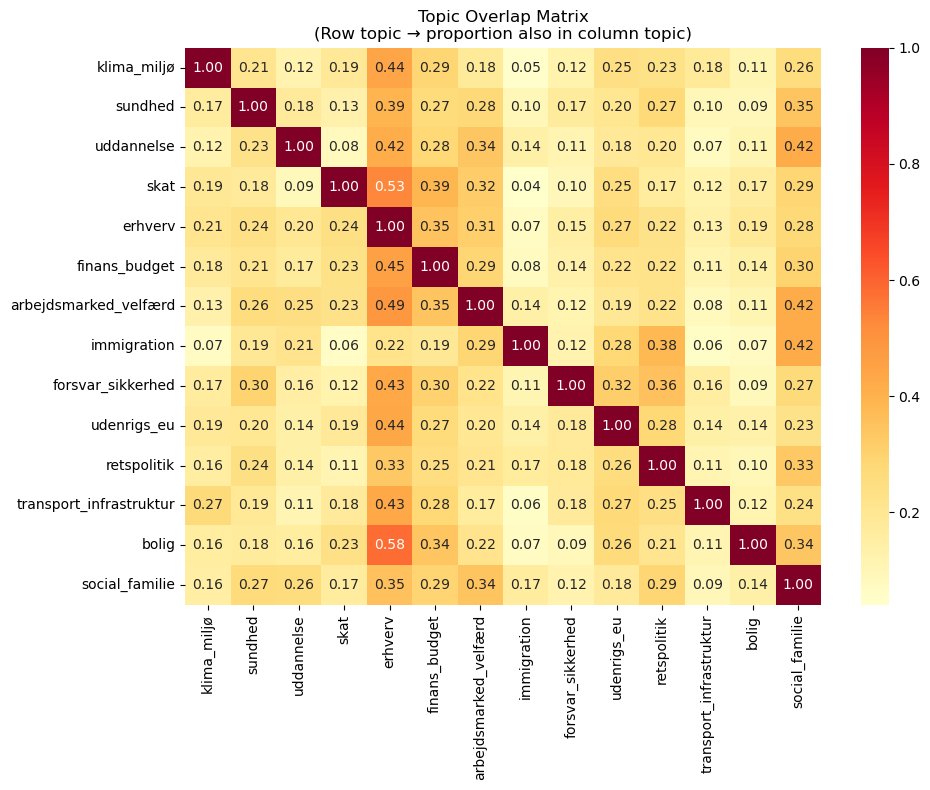

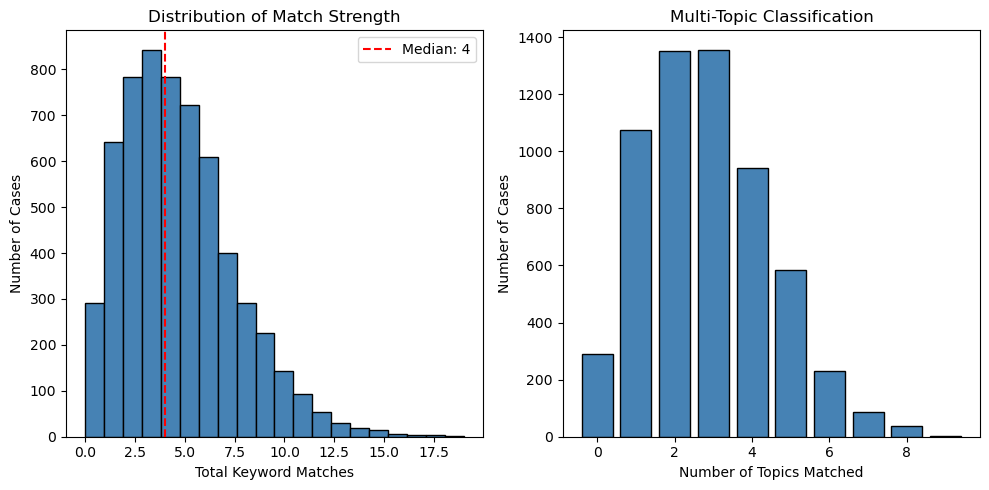

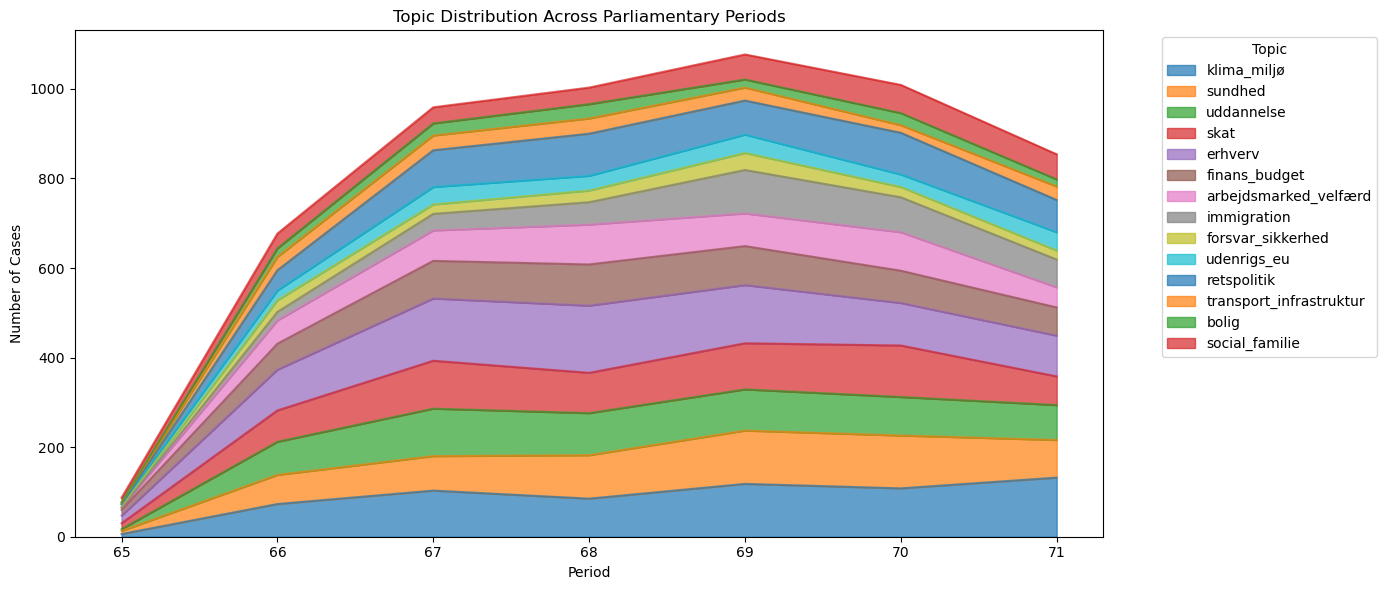

In [16]:
classified_df, stats = run_full_analysis(
    df=df_votings_type1,
    text_column='topic_texts',  # Column with text data
    period_column='Period',  # Your period column name
    threshold=1,             # Minimum matches to assign topic
    save_plots=True
)


FOLKETINGET TOPIC CLASSIFICATION PIPELINE

[1/5] Stemming keywords...
      14 topics with 179 total stemmed keywords

[2/5] Classifying 5 cases...
      Done!

[3/5] Computing statistics...

      COVERAGE STATISTICS:
      Total cases:      5
      Classified:       5 (100.0%)
      Unclassified:     0 (0.0%)
      Multi-topic:      4 (80.0%)

      TOPIC STATISTICS:
                  topic  primary_count  any_count  avg_score_when_present
            klima_miljø              1          1                     3.0
                   skat              1          1                     4.0
  arbejdsmarked_velfærd              1          1                     3.0
            immigration              1          1                     4.0
            retspolitik              1          1                     2.0
                sundhed              0          0                     0.0
             uddannelse              0          0                     0.0
                erhverv             

/var/folders/7f/_d1gswbx4hngxw3tp2m2k9kr0000gn/T/ipykernel_30006/2294124307.py:344: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/var/folders/7f/_d1gswbx4hngxw3tp2m2k9kr0000gn/T/ipykernel_30006/2294124307.py:354: RuntimeWarning: invalid value encountered in divide
  normalized = overlap_matrix.values / diag[:, np.newaxis]



[5/5] Packaging results...

PIPELINE COMPLETE

Classified data:
   case_id                                          title  \
0        1  Forslag til lov om ændring af udlændingeloven   
1        2      Forslag til lov om ændring af skatteloven   
2        3                  Forslag om klimahandlingsplan   
3        4                    Forslag til lov om dagpenge   
4        5        Forslag til lov om politiets virksomhed   

           primary_topic                        all_topics  total_matches  
0            immigration     [immigration, social_familie]              5  
1                   skat                   [skat, erhverv]              5  
2            klima_miljø                     [klima_miljø]              3  
3  arbejdsmarked_velfærd  [erhverv, arbejdsmarked_velfærd]              4  
4            retspolitik            [erhverv, retspolitik]              3  


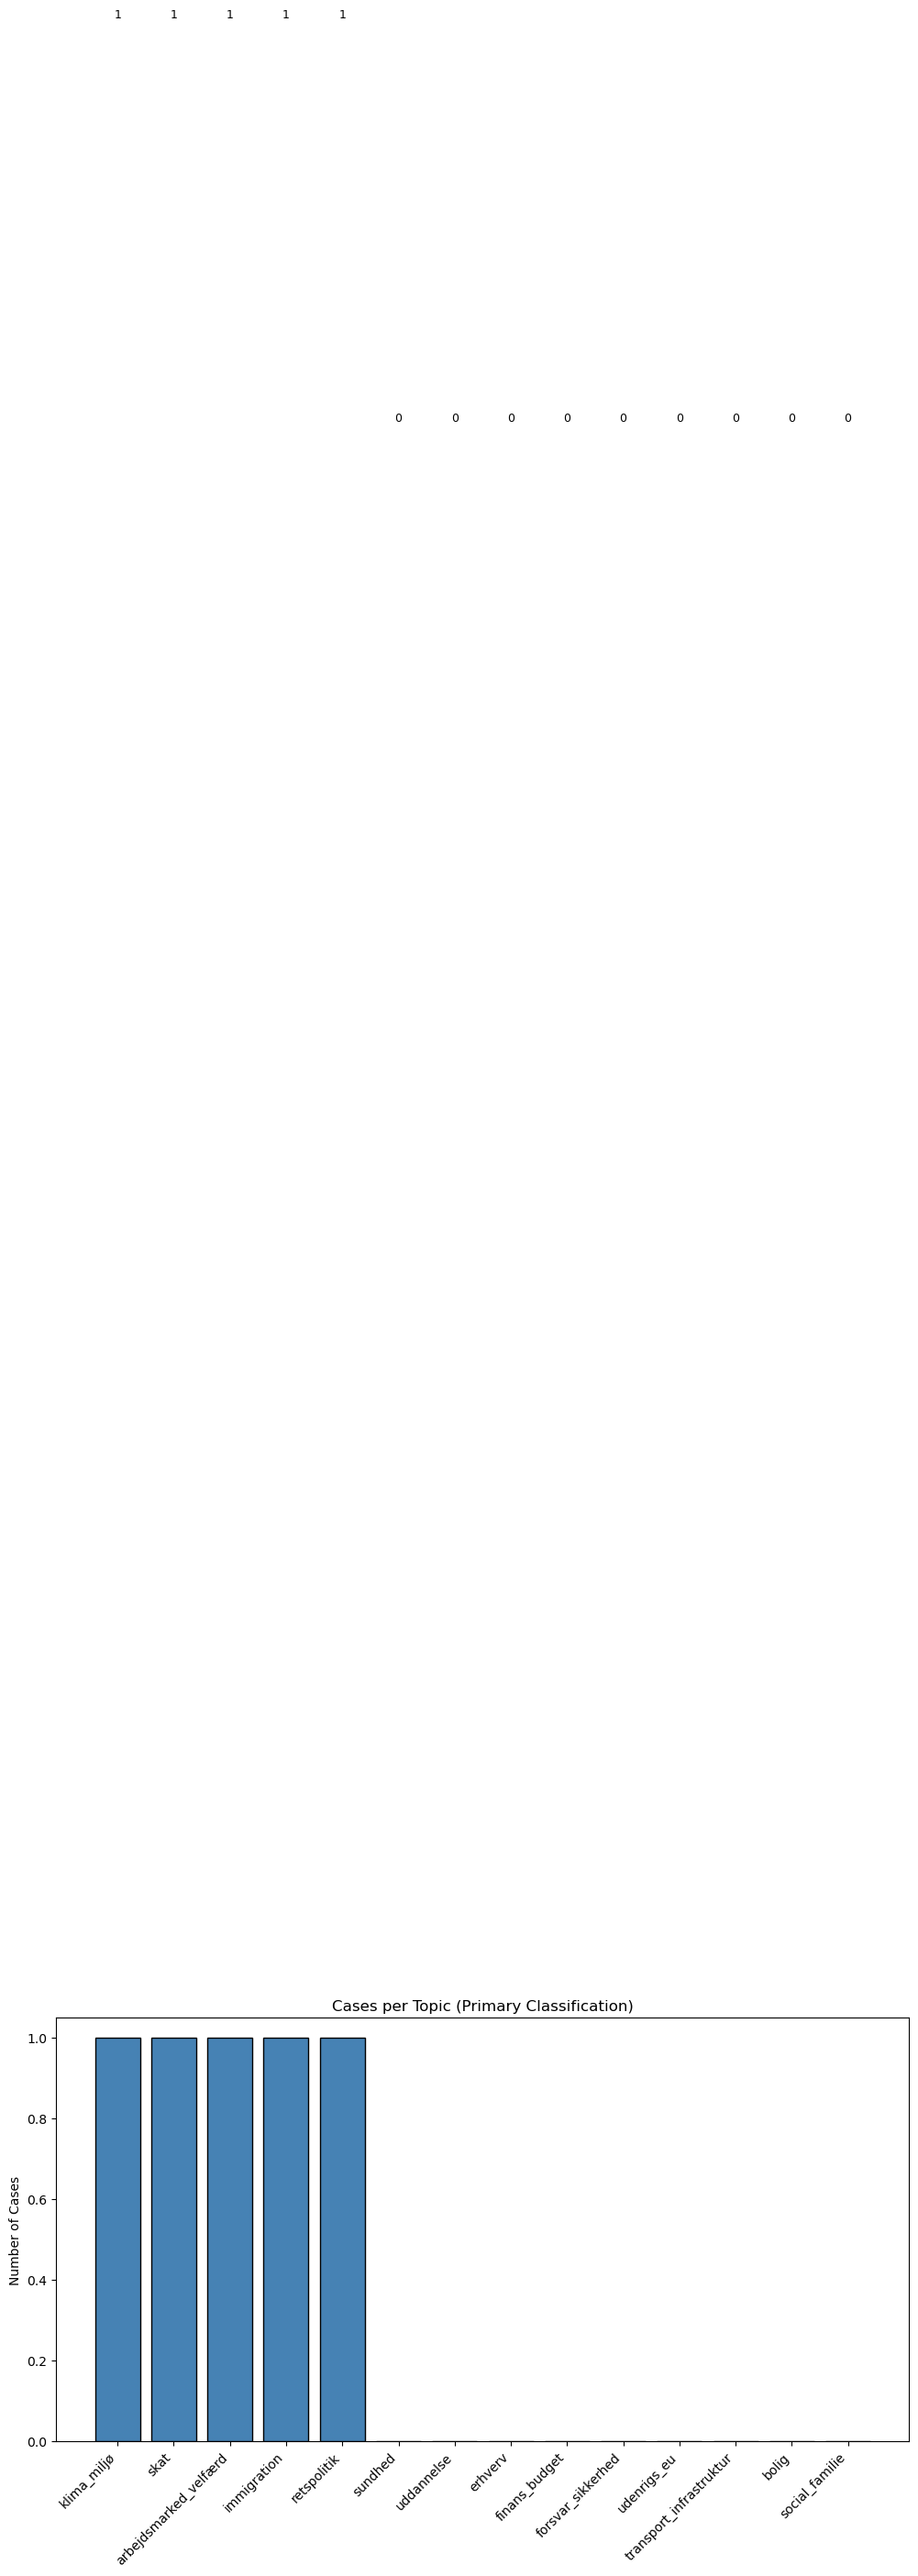

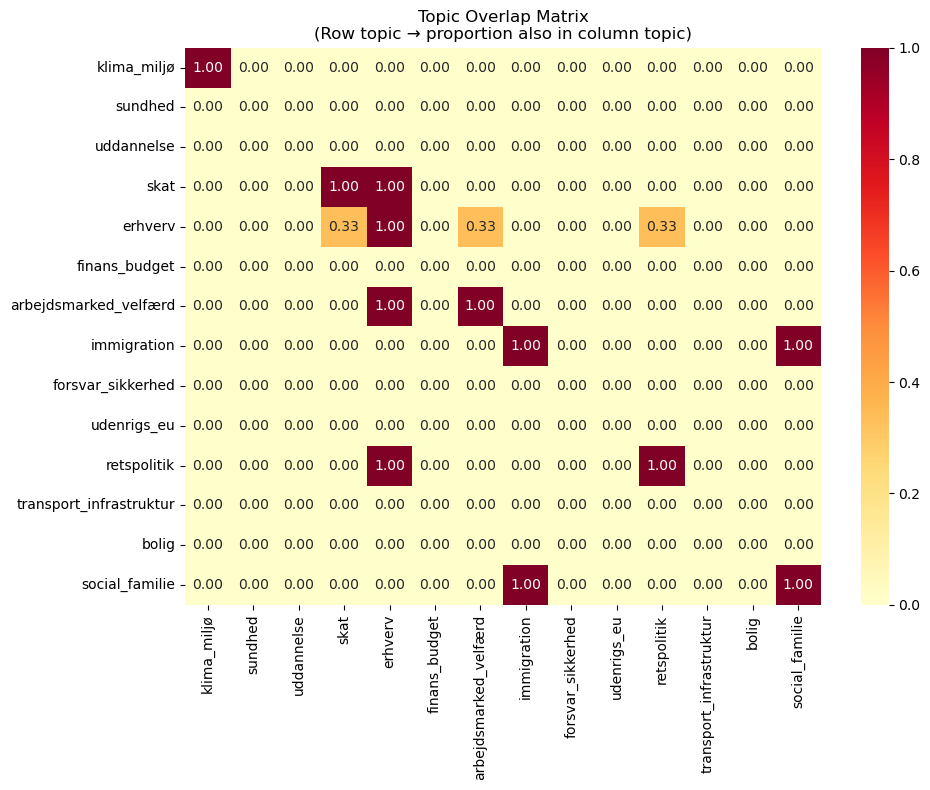

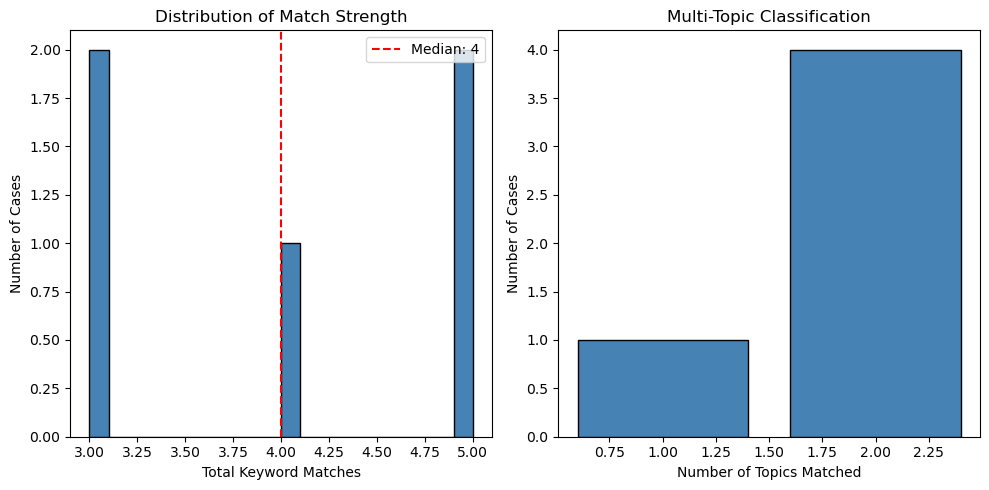

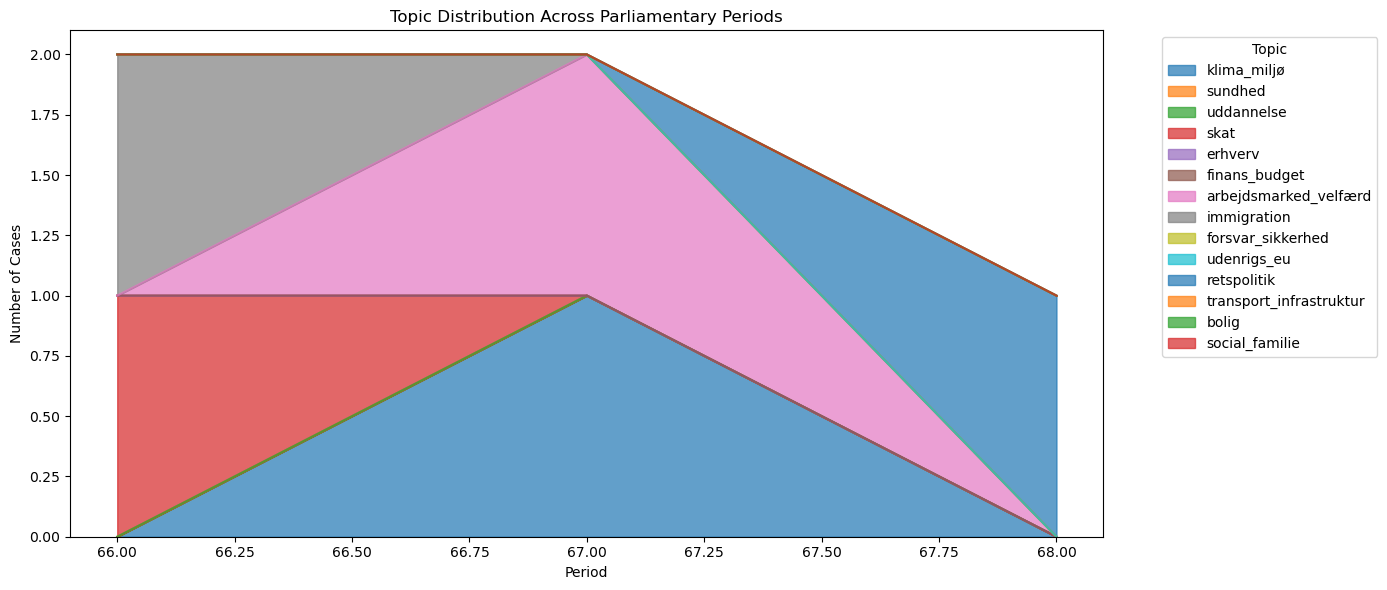

In [15]:
"""
Folketinget Topic Classification Pipeline
=========================================
Classifies parliamentary cases by policy topic using stemmed keyword matching.
Produces exploratory statistics and visualizations.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.stem.snowball import SnowballStemmer
from collections import Counter
import re

# Initialize Danish stemmer
stemmer = SnowballStemmer("danish")

# =============================================================================
# TOPIC KEYWORDS
# =============================================================================

TOPIC_KEYWORDS = {
    'klima_miljø': [
        'klima', 'miljø', 'grøn', 'co2', 'klimaforandring', 'energi', 
        'vindmølle', 'solcelle', 'forurening', 'bæredygtig', 'affald', 
        'genanvendelse', 'natur', 'biodiversitet', 'emission', 'vedvarende'
    ],
    
    'sundhed': [
        'sundhed', 'vaccine', 'pandemi', 'covid', 'corona', 'medicin', 
        'sygehus', 'hospital', 'patient', 'læge', 'sygeplejerske', 'psykiatri',
        'apotek', 'sundhedsvæsen', 'behandling', 'sygdom'
    ],
    
    'uddannelse': [
        'uddannelse', 'skole', 'universitet', 'lærer', 'elev', 
        'studerende', 'undervisning', 'folkeskole', 'gymnasium',
        'erhvervsuddannelse', 'forskning', 'videregående'
    ],

    'skat': [
    'skat', 'afgift', 'moms', 'selskabsskat', 'fradrag', 
    'skattepligtig', 'indkomstskat', 'told', 'beskatning',
    'skattefradrag', 'skattelettelse', 'skattepligt'
    ],

    'erhverv': [
        'virksomhed', 'erhverv', 'konkurrence', 'iværksætter', 
        'selskab', 'marked', 'handel', 'eksport', 'import',
        'erhvervsliv', 'vækst', 'startup'
    ],

    'finans_budget': [
        'budget', 'finans', 'finanslov', 'udgift', 'bevilling',
        'statskasse', 'offentlig', 'udgiftspolitik', 'statsbudget'
    ],
    
    'arbejdsmarked_velfærd': [
        'arbejdsmarked', 'job', 'løn', 'pension', 'dagpenge', 'beskæftigelse',
        'kontanthjælp', 'overførsel', 'arbejdsløs', 'ledighed', 'fagforening',
        'barsel', 'sygedagpenge', 'efterløn', 'førtidspension', 'velfærd'
    ],
    
    'immigration': [
        'immigration', 'indvandring', 'asyl', 'flygtning', 
        'udlænding', 'opholdstilladelse', 'statsborgerskab', 
        'integration', 'familiesammenføring', 'visum', 'grænsekontrol',
        'udvisning', 'ophold', 'indrejse'
    ],
    
    'forsvar_sikkerhed': [
        'forsvar', 'militær', 'nato', 'våben', 'veteran', 'beredskab',
        'cyber', 'sikkerhed', 'terror', 'forsvaret', 'hær', 'flåde'
    ],
    
    'udenrigs_eu': [
        'eu', 'europa', 'udenrig', 'international', 'udviklingsbistand',
        'diplomati', 'ambassade', 'handelsaftale', 'union', 'grænse',
        'eksport', 'import', 'europæisk'
    ],
    
    'retspolitik': [
        'politi', 'kriminalitet', 'retsvæsen', 'straf', 'fængsel', 
        'domstol', 'dommer', 'retspleje', 'kriminel', 'forbrydelse',
        'vold', 'tyveri', 'anklage', 'dom'
    ],
    
    'transport_infrastruktur': [
        'transport', 'infrastruktur', 'vej', 'tog', 'kollektiv', 
        'metro', 'jernbane', 'cykel', 'trafik', 'lufthavn', 'bro',
        'motorvej', 'bil', 'kørsel'
    ],
    
    'bolig': [
        'bolig', 'husleje', 'ejendom', 'almen', 'lejlighed', 
        'boligstøtte', 'lejer', 'udlejer', 'andel', 'ejerbolig'
    ],
    
    'social_familie': [
        'social', 'børn', 'familie', 'ældre', 'handicap',
        'plejehjem', 'børnepasning', 'daginstitution', 'ældrepleje',
        'børnefamilie', 'adoption', 'forældremyndighed'
    ]
}

# =============================================================================
# STEMMING FUNCTIONS
# =============================================================================

def stem_word(word):
    """Stem a single Danish word"""
    return stemmer.stem(word.lower())

def stem_keyword_dict(keyword_dict):
    """Stem all keywords in the topic dictionary"""
    stemmed = {}
    for topic, words in keyword_dict.items():
        stemmed[topic] = list(set([stem_word(w) for w in words]))
    return stemmed

def tokenize_and_stem(text):
    """
    Tokenize Danish text and stem each token.
    Returns a set of unique stemmed tokens.
    """
    if pd.isna(text) or text is None:
        return set()
    
    # Lowercase and extract Danish words (including æ, ø, å)
    tokens = re.findall(r'[a-zæøå]+', text.lower())
    
    # Stem each token
    stemmed = [stem_word(t) for t in tokens if len(t) > 2]  # Skip very short tokens
    
    return set(stemmed)

# =============================================================================
# CLASSIFICATION FUNCTIONS
# =============================================================================

def classify_case(text, stemmed_keywords, use_substring=True):
    """
    Classify a case by counting keyword matches per topic.
    
    Parameters:
    -----------
    text : str
        The case description (resume + title)
    stemmed_keywords : dict
        Topic -> list of stemmed keywords
    use_substring : bool
        If True, also check for substring matches (helps with compound words)
    
    Returns:
    --------
    dict : topic -> match count
    """
    stemmed_tokens = tokenize_and_stem(text)
    
    scores = {}
    matched_keywords = {}  # For debugging/inspection
    
    for topic, stems in stemmed_keywords.items():
        matches = []
        
        for stem in stems:
            # Direct match
            if stem in stemmed_tokens:
                matches.append(stem)
            # Substring match for compound words (if enabled)
            elif use_substring:
                for token in stemmed_tokens:
                    if len(stem) >= 4 and stem in token:
                        matches.append(f"{stem}(in:{token})")
                        break
        
        scores[topic] = len(matches)
        matched_keywords[topic] = matches
    
    return scores, matched_keywords

def assign_topics(scores, threshold=1):
    """
    Assign topic labels based on scores.
    
    Returns:
    --------
    primary_topic : str or None
        The highest-scoring topic (None if no matches)
    all_topics : list
        All topics meeting the threshold
    """
    # Filter to topics meeting threshold
    qualifying = {t: s for t, s in scores.items() if s >= threshold}
    
    if not qualifying:
        return None, []
    
    # Primary = highest score
    primary = max(qualifying, key=qualifying.get)
    all_topics = list(qualifying.keys())
    
    return primary, all_topics

# =============================================================================
# BATCH CLASSIFICATION
# =============================================================================

def classify_all_cases(df, text_column, stemmed_keywords, threshold=1):
    """
    Classify all cases in a DataFrame.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing cases
    text_column : str
        Name of column containing text to classify (e.g., 'resume' or combined)
    stemmed_keywords : dict
        Stemmed keyword dictionary
    threshold : int
        Minimum keyword matches to assign a topic
    
    Returns:
    --------
    pd.DataFrame : Original df with added classification columns
    """
    results = []
    
    for idx, row in df.iterrows():
        text = row[text_column]
        scores, matched = classify_case(text, stemmed_keywords)
        primary, all_topics = assign_topics(scores, threshold)
        
        results.append({
            'primary_topic': primary,
            'all_topics': all_topics,
            'topic_count': len(all_topics),
            'total_matches': sum(scores.values()),
            **{f'score_{t}': s for t, s in scores.items()}
        })
    
    result_df = pd.DataFrame(results)
    return pd.concat([df.reset_index(drop=True), result_df], axis=1)

# =============================================================================
# EXPLORATORY STATISTICS
# =============================================================================

def compute_coverage_stats(df):
    """Compute coverage statistics"""
    total = len(df)
    classified = (df['primary_topic'].notna()).sum()
    unclassified = (df['primary_topic'].isna()).sum()
    multi_topic = (df['topic_count'] > 1).sum()
    
    stats = {
        'total_cases': total,
        'classified': classified,
        'classified_pct': 100 * classified / total,
        'unclassified': unclassified,
        'unclassified_pct': 100 * unclassified / total,
        'multi_topic': multi_topic,
        'multi_topic_pct': 100 * multi_topic / total
    }
    
    return stats

def compute_topic_stats(df, topics):
    """Compute per-topic statistics"""
    stats = []
    
    for topic in topics:
        # Cases where this is primary topic
        primary_count = (df['primary_topic'] == topic).sum()
        
        # Cases where this topic appears at all
        any_count = df['all_topics'].apply(lambda x: topic in x if x else False).sum()
        
        # Average score when topic is present
        score_col = f'score_{topic}'
        if score_col in df.columns:
            avg_score = df[df[score_col] > 0][score_col].mean()
        else:
            avg_score = 0
        
        stats.append({
            'topic': topic,
            'primary_count': primary_count,
            'any_count': any_count,
            'avg_score_when_present': round(avg_score, 2) if not pd.isna(avg_score) else 0
        })
    
    return pd.DataFrame(stats).sort_values('primary_count', ascending=False)

def compute_overlap_matrix(df, topics):
    """Compute topic co-occurrence matrix"""
    matrix = pd.DataFrame(0, index=topics, columns=topics)
    
    for _, row in df.iterrows():
        if row['all_topics']:
            for t1 in row['all_topics']:
                for t2 in row['all_topics']:
                    if t1 in topics and t2 in topics:
                        matrix.loc[t1, t2] += 1
    
    return matrix

def compute_period_distribution(df, period_column, topics):
    """Compute topic distribution across periods"""
    # Cross-tabulation of primary topic by period
    crosstab = pd.crosstab(df[period_column], df['primary_topic'])
    
    # Ensure all topics are present
    for topic in topics:
        if topic not in crosstab.columns:
            crosstab[topic] = 0
    
    return crosstab[topics]

# =============================================================================
# VISUALIZATION FUNCTIONS
# =============================================================================

def plot_topic_distribution(topic_stats, figsize=(12, 6)):
    """Bar chart of cases per topic"""
    fig, ax = plt.subplots(figsize=figsize)
    
    topics = topic_stats['topic']
    counts = topic_stats['primary_count']
    
    bars = ax.bar(range(len(topics)), counts, color='steelblue', edgecolor='black')
    ax.set_xticks(range(len(topics)))
    ax.set_xticklabels(topics, rotation=45, ha='right')
    ax.set_ylabel('Number of Cases')
    ax.set_title('Cases per Topic (Primary Classification)')
    
    # Add count labels on bars
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                str(count), ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    return fig

def plot_overlap_heatmap(overlap_matrix, figsize=(10, 8)):
    """Heatmap of topic co-occurrence"""
    fig, ax = plt.subplots(figsize=figsize)
    
    # Normalize by diagonal (self-co-occurrence = topic count)
    # This shows proportion of overlap
    diag = np.diag(overlap_matrix.values)
    normalized = overlap_matrix.values / diag[:, np.newaxis]
    normalized = np.nan_to_num(normalized)  # Handle division by zero
    
    sns.heatmap(normalized, annot=True, fmt='.2f', cmap='YlOrRd',
                xticklabels=overlap_matrix.columns,
                yticklabels=overlap_matrix.index,
                ax=ax)
    ax.set_title('Topic Overlap Matrix\n(Row topic → proportion also in column topic)')
    plt.tight_layout()
    return fig

def plot_period_distribution(period_dist, figsize=(14, 6)):
    """Stacked area chart of topics over periods"""
    fig, ax = plt.subplots(figsize=figsize)
    
    period_dist.plot(kind='area', stacked=True, ax=ax, alpha=0.7)
    ax.set_xlabel('Period')
    ax.set_ylabel('Number of Cases')
    ax.set_title('Topic Distribution Across Parliamentary Periods')
    ax.legend(title='Topic', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    return fig

def plot_match_strength_histogram(df, figsize=(10, 5)):
    """Histogram of keyword match counts"""
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Total matches
    axes[0].hist(df['total_matches'], bins=20, color='steelblue', edgecolor='black')
    axes[0].set_xlabel('Total Keyword Matches')
    axes[0].set_ylabel('Number of Cases')
    axes[0].set_title('Distribution of Match Strength')
    axes[0].axvline(df['total_matches'].median(), color='red', linestyle='--', 
                    label=f"Median: {df['total_matches'].median():.0f}")
    axes[0].legend()
    
    # Topic count
    topic_counts = df['topic_count'].value_counts().sort_index()
    axes[1].bar(topic_counts.index, topic_counts.values, color='steelblue', edgecolor='black')
    axes[1].set_xlabel('Number of Topics Matched')
    axes[1].set_ylabel('Number of Cases')
    axes[1].set_title('Multi-Topic Classification')
    
    plt.tight_layout()
    return fig

# =============================================================================
# MAIN PIPELINE
# =============================================================================

def run_full_analysis(df, text_column, period_column=None, threshold=1, save_plots=True):
    """
    Run the complete topic classification and analysis pipeline.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with cases
    text_column : str
        Column containing text to classify
    period_column : str or None
        Column containing period identifier (optional)
    threshold : int
        Minimum matches to assign topic
    save_plots : bool
        Whether to save plots to files
    
    Returns:
    --------
    classified_df : pd.DataFrame
        DataFrame with classification results
    stats : dict
        Dictionary of all computed statistics
    """
    print("=" * 60)
    print("FOLKETINGET TOPIC CLASSIFICATION PIPELINE")
    print("=" * 60)
    
    # Step 1: Stem keywords
    print("\n[1/5] Stemming keywords...")
    stemmed_keywords = stem_keyword_dict(TOPIC_KEYWORDS)
    topics = list(stemmed_keywords.keys())
    print(f"      {len(topics)} topics with {sum(len(v) for v in stemmed_keywords.values())} total stemmed keywords")
    
    # Step 2: Classify all cases
    print(f"\n[2/5] Classifying {len(df)} cases...")
    classified_df = classify_all_cases(df, text_column, stemmed_keywords, threshold)
    print("      Done!")
    
    # Step 3: Compute statistics
    print("\n[3/5] Computing statistics...")
    
    coverage = compute_coverage_stats(classified_df)
    print(f"\n      COVERAGE STATISTICS:")
    print(f"      Total cases:      {coverage['total_cases']}")
    print(f"      Classified:       {coverage['classified']} ({coverage['classified_pct']:.1f}%)")
    print(f"      Unclassified:     {coverage['unclassified']} ({coverage['unclassified_pct']:.1f}%)")
    print(f"      Multi-topic:      {coverage['multi_topic']} ({coverage['multi_topic_pct']:.1f}%)")
    
    topic_stats = compute_topic_stats(classified_df, topics)
    print(f"\n      TOPIC STATISTICS:")
    print(topic_stats.to_string(index=False))
    
    overlap = compute_overlap_matrix(classified_df, topics)
    
    period_dist = None
    if period_column and period_column in df.columns:
        period_dist = compute_period_distribution(classified_df, period_column, topics)
        print(f"\n      PERIOD DISTRIBUTION:")
        print(period_dist)
    
    # Step 4: Create visualizations
    print("\n[4/5] Creating visualizations...")
    
    fig1 = plot_topic_distribution(topic_stats)
    fig2 = plot_overlap_heatmap(overlap)
    fig3 = plot_match_strength_histogram(classified_df)
    
    if period_dist is not None:
        fig4 = plot_period_distribution(period_dist)
    
    if save_plots:
        fig1.savefig('topic_distribution.png', dpi=150, bbox_inches='tight')
        fig2.savefig('topic_overlap.png', dpi=150, bbox_inches='tight')
        fig3.savefig('match_strength.png', dpi=150, bbox_inches='tight')
        if period_dist is not None:
            fig4.savefig('period_distribution.png', dpi=150, bbox_inches='tight')
        print("      Plots saved!")
    
    # Step 5: Package results
    print("\n[5/5] Packaging results...")
    
    stats = {
        'coverage': coverage,
        'topic_stats': topic_stats,
        'overlap_matrix': overlap,
        'period_distribution': period_dist,
        'stemmed_keywords': stemmed_keywords
    }
    
    print("\n" + "=" * 60)
    print("PIPELINE COMPLETE")
    print("=" * 60)
    
    return classified_df, stats

# =============================================================================
# EXAMPLE USAGE
# =============================================================================

if __name__ == "__main__":
    # Example: Create sample data
    sample_data = pd.DataFrame({
        'case_id': [1, 2, 3, 4, 5],
        'period': [66, 66, 67, 67, 68],
        'title': [
            'Forslag til lov om ændring af udlændingeloven',
            'Forslag til lov om ændring af skatteloven',
            'Forslag om klimahandlingsplan',
            'Forslag til lov om dagpenge',
            'Forslag til lov om politiets virksomhed'
        ],
        'resume': [
            'Loven ændrer reglerne for asyl og familiesammenføring for flygtninge.',
            'Loven ændrer virksomhedsskatteordningen og skattepligtige fradrag.',
            'Planen indeholder mål for CO2-reduktion og grøn energi.',
            'Loven ændrer reglerne for dagpenge og beskæftigelse på arbejdsmarkedet.',
            'Loven styrker politiets muligheder for at bekæmpe kriminalitet.'
        ]
    })
    
    # Combine title and resume for classification
    sample_data['text'] = sample_data['title'] + ' ' + sample_data['resume']
    
    # Run pipeline
    classified, stats = run_full_analysis(
        df=sample_data,
        text_column='text',
        period_column='period',
        threshold=1,
        save_plots=False
    )
    
    # Show results
    print("\nClassified data:")
    print(classified[['case_id', 'title', 'primary_topic', 'all_topics', 'total_matches']])

In [7]:
from nltk.stem.snowball import SnowballStemmer

stemmer = SnowballStemmer("danish")

# Examples
print(stemmer.stem("flygtninge"))      # → flygtning
print(stemmer.stem("flygtningestrømme")) # → flygtningestrøm
print(stemmer.stem("skatteloven"))     # → skattelov
print(stemmer.stem("beskæftigelse"))   # → beskæftig
print(stemmer.stem("udlændinge"))      # → udlænding
print(stemmer.stem("arbejdsmarkedet")) # → arbejdsmark

flygtning
flygtningestrøm
skattelov
beskæftig
udlænding
arbejdsmarked


In [ ]:
"""
Folketinget Topic Classification Pipeline
=========================================
Classifies parliamentary cases by policy topic using stemmed keyword matching.
Produces exploratory statistics and visualizations.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.stem.snowball import SnowballStemmer
from collections import Counter
import re

# Initialize Danish stemmer
stemmer = SnowballStemmer("danish")

# =============================================================================
# TOPIC KEYWORDS
# =============================================================================

TOPIC_KEYWORDS = {
    'klima_miljø': [
        'klima', 'miljø', 'grøn', 'co2', 'klimaforandring', 'energi', 
        'vindmølle', 'solcelle', 'forurening', 'bæredygtig', 'affald', 
        'genanvendelse', 'natur', 'biodiversitet', 'emission', 'vedvarende'
    ],
    
    'sundhed': [
        'sundhed', 'vaccine', 'pandemi', 'covid', 'corona', 'medicin', 
        'sygehus', 'hospital', 'patient', 'læge', 'sygeplejerske', 'psykiatri',
        'apotek', 'sundhedsvæsen', 'behandling', 'sygdom'
    ],
    
    'uddannelse': [
        'uddannelse', 'skole', 'universitet', 'lærer', 'elev', 
        'studerende', 'undervisning', 'folkeskole', 'gymnasium',
        'erhvervsuddannelse', 'forskning', 'videregående'
    ],
    
    'skat_økonomi': [
        'skat', 'afgift', 'moms', 'selskabsskat', 'fradrag', 'økonomi',
        'budget', 'finans', 'virksomhed', 'erhverv', 'konkurrence',
        'told', 'skattepligtig', 'indkomstskat'
    ],
    
    'arbejdsmarked_velfærd': [
        'arbejdsmarked', 'job', 'løn', 'pension', 'dagpenge', 'beskæftigelse',
        'kontanthjælp', 'overførsel', 'arbejdsløs', 'ledighed', 'fagforening',
        'barsel', 'sygedagpenge', 'efterløn', 'førtidspension', 'velfærd'
    ],
    
    'immigration': [
        'immigration', 'indvandring', 'asyl', 'flygtning', 
        'udlænding', 'opholdstilladelse', 'statsborgerskab', 
        'integration', 'familiesammenføring', 'visum', 'grænsekontrol',
        'udvisning', 'ophold', 'indrejse'
    ],
    
    'forsvar_sikkerhed': [
        'forsvar', 'militær', 'nato', 'våben', 'veteran', 'beredskab',
        'cyber', 'sikkerhed', 'terror', 'forsvaret', 'hær', 'flåde'
    ],
    
    'udenrigs_eu': [
        'eu', 'europa', 'udenrig', 'international', 'udviklingsbistand',
        'diplomati', 'ambassade', 'handelsaftale', 'union', 'grænse',
        'eksport', 'import', 'europæisk'
    ],
    
    'retspolitik': [
        'politi', 'kriminalitet', 'retsvæsen', 'straf', 'fængsel', 
        'domstol', 'dommer', 'retspleje', 'kriminel', 'forbrydelse',
        'vold', 'tyveri', 'anklage', 'dom'
    ],
    
    'transport_infrastruktur': [
        'transport', 'infrastruktur', 'vej', 'tog', 'kollektiv', 
        'metro', 'jernbane', 'cykel', 'trafik', 'lufthavn', 'bro',
        'motorvej', 'bil', 'kørsel'
    ],
    
    'bolig': [
        'bolig', 'husleje', 'ejendom', 'almen', 'lejlighed', 
        'boligstøtte', 'lejer', 'udlejer', 'andel', 'ejerbolig'
    ],
    
    'social_familie': [
        'social', 'børn', 'familie', 'ældre', 'handicap',
        'plejehjem', 'børnepasning', 'daginstitution', 'ældrepleje',
        'børnefamilie', 'adoption', 'forældremyndighed'
    ]
}


In [ ]:
# =============================================================================
# STEMMING FUNCTIONS
# =============================================================================

def stem_word(word):
    """Stem a single Danish word"""
    return stemmer.stem(word.lower())

def stem_keyword_dict(keyword_dict):
    """Stem all keywords in the topic dictionary"""
    stemmed = {}
    for topic, words in keyword_dict.items():
        stemmed[topic] = list(set([stem_word(w) for w in words]))
    return stemmed

def tokenize_and_stem(text):
    """
    Tokenize Danish text and stem each token.
    Returns a set of unique stemmed tokens.
    """
    if pd.isna(text) or text is None:
        return set()
    
    # Lowercase and extract Danish words (including æ, ø, å)
    tokens = re.findall(r'[a-zæøå]+', text.lower())
    
    # Stem each token
    stemmed = [stem_word(t) for t in tokens if len(t) > 2]  # Skip very short tokens
    
    return set(stemmed)

In [ ]:
 =============================================================================
# CLASSIFICATION FUNCTIONS
# =============================================================================

def classify_case(text, stemmed_keywords, use_substring=True):
    """
    Classify a case by counting keyword matches per topic.
    
    Parameters:
    -----------
    text : str
        The case description (resume + title)
    stemmed_keywords : dict
        Topic -> list of stemmed keywords
    use_substring : bool
        If True, also check for substring matches (helps with compound words)
    
    Returns:
    --------
    dict : topic -> match count
    """
    stemmed_tokens = tokenize_and_stem(text)
    
    scores = {}
    matched_keywords = {}  # For debugging/inspection
    
    for topic, stems in stemmed_keywords.items():
        matches = []
        
        for stem in stems:
            # Direct match
            if stem in stemmed_tokens:
                matches.append(stem)
            # Substring match for compound words (if enabled)
            elif use_substring:
                for token in stemmed_tokens:
                    if len(stem) >= 4 and stem in token:
                        matches.append(f"{stem}(in:{token})")
                        break
        
        scores[topic] = len(matches)
        matched_keywords[topic] = matches
    
    return scores, matched_keywords

def assign_topics(scores, threshold=1):
    """
    Assign topic labels based on scores.
    
    Returns:
    --------
    primary_topic : str or None
        The highest-scoring topic (None if no matches)
    all_topics : list
        All topics meeting the threshold
    """
    # Filter to topics meeting threshold
    qualifying = {t: s for t, s in scores.items() if s >= threshold}
    
    if not qualifying:
        return None, []
    
    # Primary = highest score
    primary = max(qualifying, key=qualifying.get)
    all_topics = list(qualifying.keys())
    
    return primary, all_topics

# =============================================================================
# BATCH CLASSIFICATION
# =============================================================================

def classify_all_cases(df, text_column, stemmed_keywords, threshold=1):
    """
    Classify all cases in a DataFrame.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing cases
    text_column : str
        Name of column containing text to classify (e.g., 'resume' or combined)
    stemmed_keywords : dict
        Stemmed keyword dictionary
    threshold : int
        Minimum keyword matches to assign a topic
    
    Returns:
    --------
    pd.DataFrame : Original df with added classification columns
    """
    results = []
    
    for idx, row in df.iterrows():
        text = row[text_column]
        scores, matched = classify_case(text, stemmed_keywords)
        primary, all_topics = assign_topics(scores, threshold)
        
        results.append({
            'primary_topic': primary,
            'all_topics': all_topics,
            'topic_count': len(all_topics),
            'total_matches': sum(scores.values()),
            **{f'score_{t}': s for t, s in scores.items()}
        })
    
    result_df = pd.DataFrame(results)
    return pd.concat([df.reset_index(drop=True), result_df], axis=1)

# =============================================================================
# EXPLORATORY STATISTICS
# =============================================================================

def compute_coverage_stats(df):
    """Compute coverage statistics"""
    total = len(df)
    classified = (df['primary_topic'].notna()).sum()
    unclassified = (df['primary_topic'].isna()).sum()
    multi_topic = (df['topic_count'] > 1).sum()
    
    stats = {
        'total_cases': total,
        'classified': classified,
        'classified_pct': 100 * classified / total,
        'unclassified': unclassified,
        'unclassified_pct': 100 * unclassified / total,
        'multi_topic': multi_topic,
        'multi_topic_pct': 100 * multi_topic / total
    }
    
    return stats

def compute_topic_stats(df, topics):
    """Compute per-topic statistics"""
    stats = []
    
    for topic in topics:
        # Cases where this is primary topic
        primary_count = (df['primary_topic'] == topic).sum()
        
        # Cases where this topic appears at all
        any_count = df['all_topics'].apply(lambda x: topic in x if x else False).sum()
        
        # Average score when topic is present
        score_col = f'score_{topic}'
        if score_col in df.columns:
            avg_score = df[df[score_col] > 0][score_col].mean()
        else:
            avg_score = 0
        
        stats.append({
            'topic': topic,
            'primary_count': primary_count,
            'any_count': any_count,
            'avg_score_when_present': round(avg_score, 2) if not pd.isna(avg_score) else 0
        })
    
    return pd.DataFrame(stats).sort_values('primary_count', ascending=False)

def compute_overlap_matrix(df, topics):
    """Compute topic co-occurrence matrix"""
    matrix = pd.DataFrame(0, index=topics, columns=topics)
    
    for _, row in df.iterrows():
        if row['all_topics']:
            for t1 in row['all_topics']:
                for t2 in row['all_topics']:
                    if t1 in topics and t2 in topics:
                        matrix.loc[t1, t2] += 1
    
    return matrix

def compute_period_distribution(df, period_column, topics):
    """Compute topic distribution across periods"""
    # Cross-tabulation of primary topic by period
    crosstab = pd.crosstab(df[period_column], df['primary_topic'])
    
    # Ensure all topics are present
    for topic in topics:
        if topic not in crosstab.columns:
            crosstab[topic] = 0
    
    return crosstab[topics]

# =============================================================================
# VISUALIZATION FUNCTIONS
# =============================================================================

def plot_topic_distribution(topic_stats, figsize=(12, 6)):
    """Bar chart of cases per topic"""
    fig, ax = plt.subplots(figsize=figsize)
    
    topics = topic_stats['topic']
    counts = topic_stats['primary_count']
    
    bars = ax.bar(range(len(topics)), counts, color='steelblue', edgecolor='black')
    ax.set_xticks(range(len(topics)))
    ax.set_xticklabels(topics, rotation=45, ha='right')
    ax.set_ylabel('Number of Cases')
    ax.set_title('Cases per Topic (Primary Classification)')
    
    # Add count labels on bars
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                str(count), ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    return fig

def plot_overlap_heatmap(overlap_matrix, figsize=(10, 8)):
    """Heatmap of topic co-occurrence"""
    fig, ax = plt.subplots(figsize=figsize)
    
    # Normalize by diagonal (self-co-occurrence = topic count)
    # This shows proportion of overlap
    diag = np.diag(overlap_matrix.values)
    normalized = overlap_matrix.values / diag[:, np.newaxis]
    normalized = np.nan_to_num(normalized)  # Handle division by zero
    
    sns.heatmap(normalized, annot=True, fmt='.2f', cmap='YlOrRd',
                xticklabels=overlap_matrix.columns,
                yticklabels=overlap_matrix.index,
                ax=ax)
    ax.set_title('Topic Overlap Matrix\n(Row topic → proportion also in column topic)')
    plt.tight_layout()
    return fig

def plot_period_distribution(period_dist, figsize=(14, 6)):
    """Stacked area chart of topics over periods"""
    fig, ax = plt.subplots(figsize=figsize)
    
    period_dist.plot(kind='area', stacked=True, ax=ax, alpha=0.7)
    ax.set_xlabel('Period')
    ax.set_ylabel('Number of Cases')
    ax.set_title('Topic Distribution Across Parliamentary Periods')
    ax.legend(title='Topic', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    return fig

def plot_match_strength_histogram(df, figsize=(10, 5)):
    """Histogram of keyword match counts"""
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Total matches
    axes[0].hist(df['total_matches'], bins=20, color='steelblue', edgecolor='black')
    axes[0].set_xlabel('Total Keyword Matches')
    axes[0].set_ylabel('Number of Cases')
    axes[0].set_title('Distribution of Match Strength')
    axes[0].axvline(df['total_matches'].median(), color='red', linestyle='--', 
                    label=f"Median: {df['total_matches'].median():.0f}")
    axes[0].legend()
    
    # Topic count
    topic_counts = df['topic_count'].value_counts().sort_index()
    axes[1].bar(topic_counts.index, topic_counts.values, color='steelblue', edgecolor='black')
    axes[1].set_xlabel('Number of Topics Matched')
    axes[1].set_ylabel('Number of Cases')
    axes[1].set_title('Multi-Topic Classification')
    
    plt.tight_layout()
    return fig

# =============================================================================
# MAIN PIPELINE
# =============================================================================

def run_full_analysis(df, text_column, period_column=None, threshold=1, save_plots=True):
    """
    Run the complete topic classification and analysis pipeline.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with cases
    text_column : str
        Column containing text to classify
    period_column : str or None
        Column containing period identifier (optional)
    threshold : int
        Minimum matches to assign topic
    save_plots : bool
        Whether to save plots to files
    
    Returns:
    --------
    classified_df : pd.DataFrame
        DataFrame with classification results
    stats : dict
        Dictionary of all computed statistics
    """
    print("=" * 60)
    print("FOLKETINGET TOPIC CLASSIFICATION PIPELINE")
    print("=" * 60)
    
    # Step 1: Stem keywords
    print("\n[1/5] Stemming keywords...")
    stemmed_keywords = stem_keyword_dict(TOPIC_KEYWORDS)
    topics = list(stemmed_keywords.keys())
    print(f"      {len(topics)} topics with {sum(len(v) for v in stemmed_keywords.values())} total stemmed keywords")
    
    # Step 2: Classify all cases
    print(f"\n[2/5] Classifying {len(df)} cases...")
    classified_df = classify_all_cases(df, text_column, stemmed_keywords, threshold)
    print("      Done!")
    
    # Step 3: Compute statistics
    print("\n[3/5] Computing statistics...")
    
    coverage = compute_coverage_stats(classified_df)
    print(f"\n      COVERAGE STATISTICS:")
    print(f"      Total cases:      {coverage['total_cases']}")
    print(f"      Classified:       {coverage['classified']} ({coverage['classified_pct']:.1f}%)")
    print(f"      Unclassified:     {coverage['unclassified']} ({coverage['unclassified_pct']:.1f}%)")
    print(f"      Multi-topic:      {coverage['multi_topic']} ({coverage['multi_topic_pct']:.1f}%)")
    
    topic_stats = compute_topic_stats(classified_df, topics)
    print(f"\n      TOPIC STATISTICS:")
    print(topic_stats.to_string(index=False))
    
    overlap = compute_overlap_matrix(classified_df, topics)
    
    period_dist = None
    if period_column and period_column in df.columns:
        period_dist = compute_period_distribution(classified_df, period_column, topics)
        print(f"\n      PERIOD DISTRIBUTION:")
        print(period_dist)
    
    # Step 4: Create visualizations
    print("\n[4/5] Creating visualizations...")
    
    fig1 = plot_topic_distribution(topic_stats)
    fig2 = plot_overlap_heatmap(overlap)
    fig3 = plot_match_strength_histogram(classified_df)
    
    if period_dist is not None:
        fig4 = plot_period_distribution(period_dist)
    
    if save_plots:
        fig1.savefig('topic_distribution.png', dpi=150, bbox_inches='tight')
        fig2.savefig('topic_overlap.png', dpi=150, bbox_inches='tight')
        fig3.savefig('match_strength.png', dpi=150, bbox_inches='tight')
        if period_dist is not None:
            fig4.savefig('period_distribution.png', dpi=150, bbox_inches='tight')
        print("      Plots saved!")
    
    # Step 5: Package results
    print("\n[5/5] Packaging results...")
    
    stats = {
        'coverage': coverage,
        'topic_stats': topic_stats,
        'overlap_matrix': overlap,
        'period_distribution': period_dist,
        'stemmed_keywords': stemmed_keywords
    }
    
    print("\n" + "=" * 60)
    print("PIPELINE COMPLETE")
    print("=" * 60)
    
    return classified_df, stats

# =============================================================================
# EXAMPLE USAGE
# =============================================================================

if __name__ == "__main__":
    # Example: Create sample data
    sample_data = pd.DataFrame({
        'case_id': [1, 2, 3, 4, 5],
        'period': [66, 66, 67, 67, 68],
        'title': [
            'Forslag til lov om ændring af udlændingeloven',
            'Forslag til lov om ændring af skatteloven',
            'Forslag om klimahandlingsplan',
            'Forslag til lov om dagpenge',
            'Forslag til lov om politiets virksomhed'
        ],
        'resume': [
            'Loven ændrer reglerne for asyl og familiesammenføring for flygtninge.',
            'Loven ændrer virksomhedsskatteordningen og skattepligtige fradrag.',
            'Planen indeholder mål for CO2-reduktion og grøn energi.',
            'Loven ændrer reglerne for dagpenge og beskæftigelse på arbejdsmarkedet.',
            'Loven styrker politiets muligheder for at bekæmpe kriminalitet.'
        ]
    })
    
    # Combine title and resume for classification
    sample_data['text'] = sample_data['title'] + ' ' + sample_data['resume']
    
    # Run pipeline
    classified, stats = run_full_analysis(
        df=sample_data,
        text_column='text',
        period_column='period',
        threshold=1,
        save_plots=False
    )
    
    # Show results
    print("\nClassified data:")
    print(classified[['case_id', 'title', 'primary_topic', 'all_topics', 'total_matches']])